In [1332]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from collections import Counter
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

## Reinforcement of Models

In [1333]:
train = pd.read_csv("../data/clean_train.csv", sep=',')
test = pd.read_csv("../data/clean_test.csv", sep=',')

In [1334]:
X = train["clean_recette"] 
y = train["type"]#.map({'Dessert':2 ,'Entrée':0, 'Plat principal':1})
X_test = test["clean_recette"]
y_test = test["type"]#.map({'Dessert':2 ,'Entrée':0, 'Plat principal':1})

In [1335]:
# train.head(2)

In [ ]:
def model_pipeline(X_train, y_train, X_test, y_test, model=None, vectorizer='tfidf', ngrams=(1,1)):
    """Data vectorizer (TD-IDF or BOW) with use of Context (n-grams)"""
    if model is None:
        raise ValueError("You must provide a model")

    if vectorizer == 'tfidf':
        pipeline = Pipeline([
            ("vectorizer", TfidfVectorizer(ngram_range=ngrams)),
            ("clf", model)
        ])
    else:
        pipeline = Pipeline([
            ("vectorizer", CountVectorizer(ngram_range=ngrams)),
            ("normalizer", Normalizer(norm='l2')),
            ("clf", model)
        ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    train_acc = pipeline.score(X_train, y_train)
    test_acc = accuracy_score(y_test, y_pred)

    results = f"Train score: {train_acc:.3f} || Test accuracy: {test_acc:.3f}"

    output = f"""
            {results}

            CONFUSION MATRIX

            {confusion_matrix(y_test, y_pred)}

            CLASSIFICATION REPORT

            {classification_report(y_test, y_pred, zero_division=0)}
            """

    return output

In [1337]:
X_train, X_val, y_train, y_val = train_test_split(X, y,  random_state=42)

In [1338]:
model1 = LogisticRegression()

In [1339]:
print(model_pipeline(X_train, y_train, X_val, y_val, model=model1))


            Train score: 0.918 || Test accuracy: 0.863

            CONFUSION MATRIX

            [[ 908    2    4]
 [  18  480  256]
 [  12  136 1303]]

            CLASSIFICATION REPORT

                            precision    recall  f1-score   support

       Dessert       0.97      0.99      0.98       914
        Entrée       0.78      0.64      0.70       754
Plat principal       0.83      0.90      0.86      1451

      accuracy                           0.86      3119
     macro avg       0.86      0.84      0.85      3119
  weighted avg       0.86      0.86      0.86      3119

            


In [1340]:
print(model_pipeline(X_train, y_train, X_test, y_test, model=model1))


            Train score: 0.918 || Test accuracy: 0.870

            CONFUSION MATRIX

            [[405   1   1]
 [  5 232 100]
 [  7  66 571]]

            CLASSIFICATION REPORT

                            precision    recall  f1-score   support

       Dessert       0.97      1.00      0.98       407
        Entrée       0.78      0.69      0.73       337
Plat principal       0.85      0.89      0.87       644

      accuracy                           0.87      1388
     macro avg       0.87      0.86      0.86      1388
  weighted avg       0.87      0.87      0.87      1388

            


Le modèle Logistique est plus robuste $(très stable: (Dessert:0.98,1,0.98 | Entrée:0.78,0.69,0.73 | Plat Principal:0.85,0.89,0.87))$ que les modèles précédents. Un très bon compromis est trouvé entre précision et généraliation pour tous les types recettes. Les opérations de Normalisation on eu impacte. Le F1-Score est de 0.87

In [1341]:
model2 = SVC(kernel='linear')

In [1342]:
print(model_pipeline(X_train, y_train, X_val, y_val, model=model2))


            Train score: 0.931 || Test accuracy: 0.862

            CONFUSION MATRIX

            [[ 911    0    3]
 [  14  485  255]
 [  11  147 1293]]

            CLASSIFICATION REPORT

                            precision    recall  f1-score   support

       Dessert       0.97      1.00      0.98       914
        Entrée       0.77      0.64      0.70       754
Plat principal       0.83      0.89      0.86      1451

      accuracy                           0.86      3119
     macro avg       0.86      0.84      0.85      3119
  weighted avg       0.86      0.86      0.86      3119

            


In [1343]:
print(model_pipeline(X_train, y_train, X_test, y_test, model=model2))


            Train score: 0.931 || Test accuracy: 0.867

            CONFUSION MATRIX

            [[404   1   2]
 [  6 231 100]
 [  6  69 569]]

            CLASSIFICATION REPORT

                            precision    recall  f1-score   support

       Dessert       0.97      0.99      0.98       407
        Entrée       0.77      0.69      0.72       337
Plat principal       0.85      0.88      0.87       644

      accuracy                           0.87      1388
     macro avg       0.86      0.85      0.86      1388
  weighted avg       0.86      0.87      0.87      1388

            


Les performances sont sensiblement égales à elle de la regression Logistique. Toutefois le modèle se trompe légèrement plus sur les Entrées et plats principaux

In [1347]:
model3 = XGBClassifier(
     n_estimators=100,       # nombre d'arbres
    max_depth=3,            # profondeur modérée
    learning_rate=0.01,      # petit taux d'apprentissage
    objective='multi:softmax',  # classification multi-classes
    num_class=3,            # nombre de classes
    eval_metric='mlogloss', # métrique adaptée
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

In [1348]:
print(model_pipeline(X_train, y_train.map({'Dessert':2, 'Entrée':0, 'Plat principal':1}), 
                     X_test, y_test.map({'Dessert':2, 'Entrée':0, 'Plat principal':1}), 
                     model=model3))


            Train score: 0.732 || Test accuracy: 0.725

            CONFUSION MATRIX

            [[  2 330   5]
 [  0 636   8]
 [  0  39 368]]

            CLASSIFICATION REPORT

                          precision    recall  f1-score   support

           0       1.00      0.01      0.01       337
           1       0.63      0.99      0.77       644
           2       0.97      0.90      0.93       407

    accuracy                           0.72      1388
   macro avg       0.87      0.63      0.57      1388
weighted avg       0.82      0.72      0.63      1388

            


Le XGBoost est performant (robuste) sur les Entrée et Plat principal. Notons qu'il surapprend et donc est incapable de généraliser sur les données de Dessert.  

In [ ]:
donnees = pd.read_csv("../data/train_numericals.csv").drop(columns=['recipe'])
donnees2 = pd.read_csv("../data/test_numericals.csv").drop(columns=['recipe'])
donnees = donnees.rename(columns={"class":"target"})
donnees2 = donnees2.rename(columns={"class":"target"})
donnees.head(2)

,title_length,recipe_length,ingredients_length,recipe_freq_word,number_of_ingredient,target
0,9,107,35,poireau,13,Plat principal
1,2,56,40,faire,12,Entrée


In [ ]:
def create_category_columns(df, text_col, categories_dict):
    """
    Crée pour chaque catégorie une colonne qui compte le nombre de mots présents
    de cette catégorie dans la colonne text_col.
    
    Args:
        df : pandas DataFrame
        text_col : nom de la colonne texte
        categories_dict : dictionnaire {nom_catégorie: [liste_mots]}
        
    Returns:
        df : DataFrame avec les nouvelles colonnes ajoutées
    """
    # passer tout en minuscules pour éviter les problèmes
    df[text_col] = df[text_col].str.lower()
    
    for category, mots in categories_dict.items():
        mots = [mot.lower() for mot in mots]
        # compter le nombre d'occurrences de mots de la catégorie
        df[category] = df[text_col].apply(lambda x: sum(word in x for word in mots))
    
    return df

In [ ]:
categories = {
    "dessert": ["oreillettes", "coings", "courge","carambars","agar","nutella","abricots",
                "bailey","pêches","rhubarbe"],
    "plat": ["perdreaux", "coq", "joues", "gnocchi", 'raviolis', "pâtisson",
              "blettes","lotte","calmars","naveline"],
    "entree": ["orties", "poulpe", "bettes","récipients","crêpe","sardines",
               "betterave", "citrouille", "homard"]
}

In [ ]:
train_categories = create_category_columns(train, "recette", categories)[["dessert",	"plat",	"entree"]]

test_categories = create_category_columns(test, "recette", categories)[["dessert",	"plat",	"entree"]]

In [ ]:
train_categories.head()

,dessert,plat,entree
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,1


In [ ]:
#donnees["target"] = donnees["target"].map({"Plat principal":1, "Entree":0, "Dessert":2})
donnees[["dessert",	"plat",	"entree"]] = train_categories
donnees2[["dessert",	"plat",	"entree"]] = test_categories
donnees.head()

,title_length,recipe_length,ingredients_length,recipe_freq_word,number_of_ingredient,target,dessert,plat,entree
0,9,107,35,poireau,13,Plat principal,0,0,0
1,2,56,40,faire,12,Entrée,0,0,0
2,7,77,20,mascarpone,6,Entrée,0,0,0
3,9,25,25,mélanger,9,Dessert,0,0,0
4,4,145,56,ajouter,15,Entrée,0,0,1


In [ ]:
def tfidf_mean_per_col(text_column):

    vectorizer = TfidfVectorizer()

    # matrice TF-IDF
    tfidf_matrix = vectorizer.fit_transform(text_column)

    # moyenne des scores par ligne
    tfidf_mean = tfidf_matrix.mean(axis=1)

    return tfidf_mean.A1  # transforme en array 1D

In [ ]:
# model4 = LogisticRegression(multi_class="multinomial")

In [ ]:
# num_train = pd.read_csv("../data/train_numericals.csv")
donnees = pd.concat([donnees[['title_length', 'recipe_length', 'ingredients_length',
                                    'recipe_freq_word', 'number_of_ingredient']], 
                                     train[['clean_recette', 'clean_ingredients', 
                                            'dessert', 'plat', 'entree', 'type']]], axis=1)

In [ ]:
# num_test = pd.read_csv("../data/test_numericals.csv")
donnees2 = pd.concat([donnees2[['title_length', 'recipe_length', 'ingredients_length',
                                    'recipe_freq_word', 'number_of_ingredient']], 
                                     test[['clean_recette', 'clean_ingredients', 
                                          'dessert', 'plat', 'entree',  'type']]], axis=1)

In [ ]:
# concatenated_train_data.head(2)

In [ ]:
donnees["recette_vec"]  = np.round(10000*tfidf_mean_per_col(donnees["clean_recette"]), 2)
donnees["ingredients_vec"]  = np.round(10000*tfidf_mean_per_col(donnees["clean_ingredients"]),2)

In [ ]:
donnees2["recette_vec"]  = np.round(10000*tfidf_mean_per_col(donnees2["clean_recette"]), 2)
donnees2["ingredients_vec"]  = np.round(10000*tfidf_mean_per_col(donnees2["clean_ingredients"]),2)

In [ ]:
donnees2.head(2)

,title_length,recipe_length,ingredients_length,recipe_freq_word,number_of_ingredient,clean_recette,clean_ingredients,dessert,plat,entree,type,recette_vec,ingredients_vec
0,6,77,24,lait,9,veille préparer confiture lait porter ébulliti...,garniture 1 boîte lait concentré sucrer 40 cl ...,0,0,0,Dessert,14.46,19.50
1,3,132,49,pâte,15,croissants pétrir ingrédient faire pâte mollet...,250 gramme farine 1 pincer sel 1 cuillère soup...,0,0,0,Dessert,17.12,24.59


In [ ]:
X1 = donnees.drop(columns=["clean_recette","clean_ingredients", 'recipe_freq_word'])
X1['type']= X1['type'].map({'Dessert':2, 'Entrée':0, 'Plat principal':1})
X2 = donnees2.drop(columns=["clean_recette","clean_ingredients", 'recipe_freq_word'])
X2['type'] = X2['type'].map({'Dessert':2, 'Entrée':0, 'Plat principal':1})

In [ ]:
model3 = smf.mnlogit(formula="type ~ title_length + recipe_length + ingredients_length +" \
" number_of_ingredient + entree + plat + dessert+ recette_vec +	ingredients_vec",data=X1)
results = model3.fit()
print(results.summary())


Optimization terminated successfully.
         Current function value: 1.000036
         Iterations 6
                          MNLogit Regression Results                          
Dep. Variable:                   type   No. Observations:                12473
Model:                        MNLogit   Df Residuals:                    12453
Method:                           MLE   Df Model:                           18
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                 0.05394
Time:                        02:40:25   Log-Likelihood:                -12473.
converged:                       True   LL-Null:                       -13185.
Covariance Type:            nonrobust   LLR p-value:                2.253e-291
              type=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.3346      0.245     -1.366      0.172      -0.815       0.146

In [ ]:
# X1 = X1[["recipe_length", "entree", "plat", "dessert", "ingredients_vec"]]
# X2 = X2[["recipe_length", "entree", "plat", "dessert", "ingredients_vec"]]

In [ ]:
cor = X1.corr()

In [ ]:
X1.columns

Index(['title_length', 'recipe_length', 'ingredients_length',
       'number_of_ingredient', 'dessert', 'plat', 'entree', 'type',
       'recette_vec', 'ingredients_vec'],
      dtype='object')

In [ ]:
import seaborn as sns

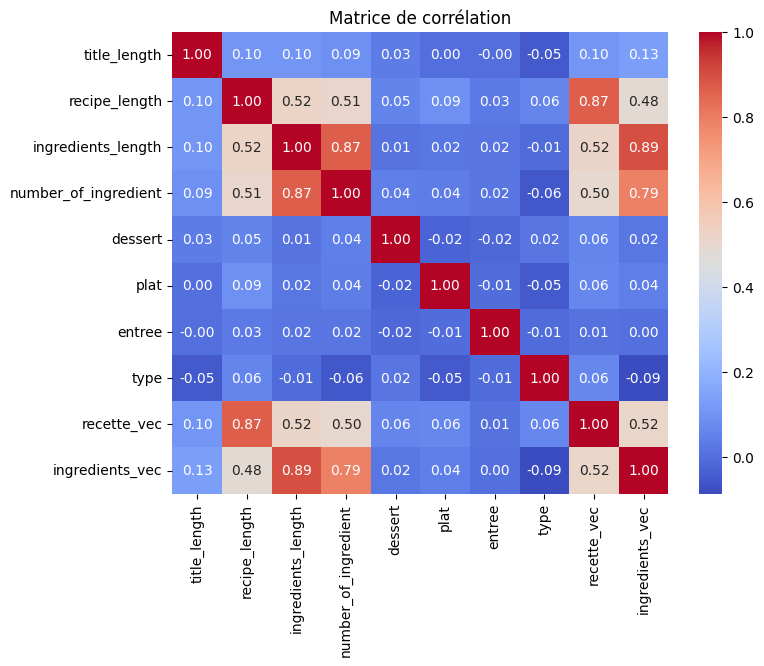

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

In [ ]:
def modelisation(X_train, y_train, X_test, y_test, model=None):
    model = model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores = model.score(X_train,y_train), accuracy_score(y_test,y_pred)
    results = f"Train score: {round(scores[0],3)} || Test accuracy: {round(scores[1],3)}"

    output =f"\n {results}\n\n CONFUSION MATRIX\n\n \
          {confusion_matrix(y_test, y_pred)}\n\n CLASSIFICATION REPORT\n\n \
            {classification_report(y_test, y_pred, zero_division=0)}"
    return output

In [ ]:
std = StandardScaler()
X1_scaled = std.fit_transform(X1)
X2_scaled = std.transform(X2)

In [ ]:
X1_scaled.shape

(12473, 10)

In [ ]:
X2_scaled.shape

(1388, 10)

In [ ]:
y = y.map({'Dessert':2, 'Entrée':0, 'Plat principal':1})
y_test =y_test.map({'Dessert':2, 'Entrée':0, 'Plat principal':1})

In [ ]:
#X_train, X_val, y_train, y_val = train_test_split(X1_scaled, y, test_size=0.2, random_state=42)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=35,       # nombre d'arbres
    max_depth=3,            # profondeur modérée
    learning_rate=0.01,      # petit taux d'apprentissage
    objective='multi:softmax',  # classification multi-classes
    num_class=3,            # nombre de classes
    eval_metric='mlogloss', # métrique adaptée
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

In [ ]:
# matches = np.isin(X1_scaled, X_val).all(axis=1)
# print("Lignes identiques train/test :", matches.sum())

In [ ]:
# print(modelisation(X1_scaled, y, X_val, y_val, model=xgb_model))

In [ ]:
print(modelisation(X1_scaled, y, X2_scaled, y_test, model=xgb_model))


 Train score: 1.0 || Test accuracy: 1.0

 CONFUSION MATRIX

           [[337   0   0]
 [  0 644   0]
 [  0   0 407]]

 CLASSIFICATION REPORT

                           precision    recall  f1-score   support

           0       1.00      1.00      1.00       337
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       407

    accuracy                           1.00      1388
   macro avg       1.00      1.00      1.00      1388
weighted avg       1.00      1.00      1.00      1388



In [ ]:
ada_model = AdaBoostClassifier()

In [ ]:
print(modelisation(X1_scaled, y, X_val, y_val, model=xgb_model))

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:clean_recette: object

In [ ]:
print(modelisation(X1_scaled, y, X2_scaled, y_test, model=ada_model))


 Train score: 1.0 || Test accuracy: 1.0

 CONFUSION MATRIX

           [[337   0   0]
 [  0 644   0]
 [  0   0 407]]

 CLASSIFICATION REPORT

                           precision    recall  f1-score   support

           0       1.00      1.00      1.00       337
           1       1.00      1.00      1.00       644
           2       1.00      1.00      1.00       407

    accuracy                           1.00      1388
   macro avg       1.00      1.00      1.00      1388
weighted avg       1.00      1.00      1.00      1388



### Word2Vec

In [ ]:
x~

SyntaxError: invalid syntax (3056518405.py, line 1)

In [ ]:
complet_documents = pd.concat([train["clean_recette"], test["clean_recette"]]
                              , ignore_index=True)

all_tokens = complet_documents.str.lower().str.split()

In [ ]:
model_w2v = Word2Vec(all_tokens.tolist(), vector_size=100, window=5, min_count=1, workers=4, sg=1)

In [ ]:
word_freq = Counter(model_w2v.wv.index_to_key)
top_100_words = [word for word, freq in word_freq.most_common(500) ]
vectors = [model_w2v.wv[word] for word in top_100_words]

In [ ]:
def w2v_vectorizer(tweets, model, vector_size=100):
    """
    Transforme une liste de tweets en vecteurs Word2Vec.
    Retourne la moyenne des vecteurs par tweet pour avoir une taille fixe.
    """
    result = []
    #absent_words = set()  # Utilisation d'un set pour éviter les doublons inutiles

    for tweet in tweets:
        # On récupère les vecteurs uniquement pour les mots présents
        valid_vectors = [model.wv[word] for word in tweet if word in model.wv]
        
        if valid_vectors:
            # On fait la moyenne des vecteurs du tweet (shape: 100,)
            tweet_average = np.mean(valid_vectors, axis=0)
            result.append(tweet_average)
        else:
            # Si aucun mot n'est connu, on met un vecteur nul (évite de casser le modèle)
            result.append(np.zeros(vector_size))
            
        # Log des mots absents (optionnel)
        #absent_words.update([word for word in tweet if word not in model.wv])

    return np.array(result)#, list(absent_words)
        

In [ ]:
x1 = w2v_vectorizer(concatenated_train_data['clean_recette'].values,
                                              model_w2v, vector_size=100)
x2 = w2v_vectorizer(concatenated_test_data['clean_recette'].values,
                                              model_w2v, vector_size=100)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30)  
X_train = pca.fit_transform(x1)
X_test = pca.transform(x2)

### Logistique Regression

In [ ]:
print(modelisation(concatenated_train_data.drop(columns=["clean_recette","type","recipe_freq_word", "clean_ingredients"]), 
                   y_train, 
                   concatenated_test_data.drop(columns=["clean_recette","type","recipe_freq_word", "clean_ingredients"]), 
                   y_test, model=LogisticRegression()))

ValueError: Found input variables with inconsistent numbers of samples: [12473, 9978]

In [ ]:
print(modelisation(X_train, y_train, X_test, y_test, model=LogisticRegression()))


 Train score: 0.524 || Test accuracy: 0.514

 CONFUSION MATRIX

           [[  1 285  51]
 [  0 580  64]
 [  0 275 132]]

 CLASSIFICATION REPORT

                           precision    recall  f1-score   support

           0       1.00      0.00      0.01       337
           1       0.51      0.90      0.65       644
           2       0.53      0.32      0.40       407

    accuracy                           0.51      1388
   macro avg       0.68      0.41      0.35      1388
weighted avg       0.64      0.51      0.42      1388



In [ ]:
print(modelisation(x1, y_train, x2, y_test, model=XGBClassifier(n_estimators=20, max_depth=3)))


 Train score: 0.602 || Test accuracy: 0.55

 CONFUSION MATRIX

           [[ 26 232  79]
 [ 20 515 109]
 [  5 179 223]]

 CLASSIFICATION REPORT

                           precision    recall  f1-score   support

           0       0.51      0.08      0.13       337
           1       0.56      0.80      0.66       644
           2       0.54      0.55      0.55       407

    accuracy                           0.55      1388
   macro avg       0.54      0.47      0.45      1388
weighted avg       0.54      0.55      0.50      1388



In [ ]:
print(modelisation(X_train, y_train, X_test, y_test, model=AdaBoostClassifier()))


 Train score: 0.575 || Test accuracy: 0.558

 CONFUSION MATRIX

           [[ 31 221  85]
 [ 31 516  97]
 [ 16 164 227]]

 CLASSIFICATION REPORT

                           precision    recall  f1-score   support

           0       0.40      0.09      0.15       337
           1       0.57      0.80      0.67       644
           2       0.56      0.56      0.56       407

    accuracy                           0.56      1388
   macro avg       0.51      0.48      0.46      1388
weighted avg       0.52      0.56      0.51      1388

